<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/ET_fractal_notebook_V42bis_metric_scan_complete_PATCHED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ET\_fractal — Notebook V4.2bis de fermeture adiabatique et pivot métrique

Ce notebook reprend la fermeture **V4.1** fondée sur la dérive adiabatique géométrique, puis ajoute une **V4.2bis**
qui corrige le scan de fermeture pour évaluer la contrainte énergétique **après raccord métrique** via le jacobien
\(J = dt/d\mathrm{Ŧ}\).

## Logique adoptée

1. **couche géométrique / cinématique du burst**
2. **fermeture observable V4.1** \((\epsilon_{eff}, \Xi_{eff}, \eta_{eff}, n_s, r)\)
3. **raccord métrique V4.2bis** pour le pivot \(\mathrm{Ŧ}_* \to t_* \to H_*^{(m)} \to V_*^{1/4}\)
4. **scan metric-aware** de la fermeture observable
5. **reheating conditionnel**
6. **exports CSV**

## Point méthodologique

Le budget d’e-folds reste calculé dans la variable géométrique du cœur de plateau, tandis que l’énergie au pivot
est lue dans la variable **métrique** issue du raccord, conformément à la logique du manuscrit.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import quad

## 1. Constantes

In [2]:
Mpl_red = 2.435e18
hbar_GeV_s = 6.582119569e-25
g_re_default = 106.75

ns_target = 0.965
ns_tol = 0.01
r_max = 0.036

Nstar_grid = np.arange(50.0, 60.1, 1.0)

## 2. Paramètres du modèle

In [3]:
p = {
    # Horloge locale effective Ŧ
    "Tbar_min": 1e-44,
    "Tbar_max": 1e-33,
    "t_cross": 5.0e-40,
    "tau_reg": 1.0e-40,

    # Variable de résolution Δτ⊙
    "delta_tau_min": 1e-6,
    "delta_tau_max": 1e+2,

    # Fond géométrique 6 -> 3
    "H_uv": 6.0,
    "H_ir": 3.0,
    "HD_delta_tau_c": 1.0,
    "HD_delta_tau_w": 0.35,

    # Résidu DSI
    "xi_amp": 0.08,
    "xi_damp": 0.25,
    "xi_omega": 8.0,
    "xi_phi": 0.0,
    "delta_tau_ref": 1.0,

    # Gating DSI en Ŧ
    "Tbar_xi": 3.0e-40,
    "Delta_xi_log": 0.60,

    # Burst inflationnaire local
    "HB_target": 29.0,
    "Tbar_on":  2.0e-41,
    "Tbar_off": 3.0e-35,
    "Tbar_w":   0.25,

    # Friction géométrique
    "beta_lo": 0.98,
    "beta_hi": 1.08,
    "beta_Tbar_c": 1.0e-38,
    "beta_Tbar_w": 0.60,

    # Diagnostics
    "A_HD_max": 0.25,
    "A_beta_max": 0.25,
    "eps2_max":  0.50,
    "eps2_core_max": 0.20,
}

## 3. Horloge locale, mapping Δτ⊙ et briques géométriques

In [4]:
def t_of_Tbar(Tbar, p):
    return p["t_cross"] - p["tau_reg"] + Tbar

def delta_tau_of_Tbar(Tbar, p):
    Tmin = p["Tbar_min"]
    Tmax = p["Tbar_max"]
    dmin = p["delta_tau_min"]
    dmax = p["delta_tau_max"]

    T = np.clip(Tbar, Tmin, Tmax)
    u = (np.log(T) - np.log(Tmin)) / (np.log(Tmax) - np.log(Tmin))
    return np.exp(np.log(dmin) + u * (np.log(dmax) - np.log(dmin)))

def H_D_background(delta_tau, p):
    dt = np.clip(delta_tau, p["delta_tau_min"], p["delta_tau_max"])
    x = (dt - p["HD_delta_tau_c"]) / p["HD_delta_tau_w"]
    s = 0.5 * (1.0 + np.tanh(x))
    return p["H_uv"] + (p["H_ir"] - p["H_uv"]) * s

def xi_DSI(delta_tau, p):
    dt = np.clip(delta_tau, p["delta_tau_min"], p["delta_tau_max"])
    X = np.log(dt / max(p["delta_tau_ref"], 1e-30))
    return p["xi_amp"] * np.exp(-p["xi_damp"] * np.abs(X)) * np.cos(p["xi_omega"] * X + p["xi_phi"])

def g_xi_of_Tbar(Tbar, p):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    Tx = max(p["Tbar_xi"], p["Tbar_min"])
    return 0.5 * (1.0 - np.tanh((np.log(T) - np.log(Tx)) / p["Delta_xi_log"]))

def burst_window(Tbar, p):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    X = np.log(T)
    Xon = np.log(p["Tbar_on"])
    Xoff = np.log(p["Tbar_off"])
    sig = p["Tbar_w"]

    left  = 0.5 * (1.0 + np.tanh((X - Xon) / sig))
    right = 0.5 * (1.0 + np.tanh((X - Xoff) / sig))
    return np.clip(left - right, 0.0, 1.0)

def B_inf(Tbar, p):
    return (p["HB_target"] - p["H_uv"]) * burst_window(Tbar, p)

def beta_of_Tbar(Tbar, p):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    Tc = max(p["beta_Tbar_c"], p["Tbar_min"])
    X = (np.log(T) - np.log(Tc)) / p["beta_Tbar_w"]
    s = 0.5 * (1.0 + np.tanh(X))
    return p["beta_lo"] + (p["beta_hi"] - p["beta_lo"]) * s

def H_D_bg_of_Tbar(Tbar, p):
    return H_D_background(delta_tau_of_Tbar(Tbar, p), p)

def xi_of_Tbar(Tbar, p):
    return xi_DSI(delta_tau_of_Tbar(Tbar, p), p)

def Xi_struct_of_Tbar(Tbar, p):
    return abs(g_xi_of_Tbar(Tbar, p) * xi_of_Tbar(Tbar, p))

def H_D_eff_of_Tbar(Tbar, p):
    return H_D_bg_of_Tbar(Tbar, p) + B_inf(Tbar, p) + g_xi_of_Tbar(Tbar, p) * xi_of_Tbar(Tbar, p)

def p_eff_of_Tbar(Tbar, p):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    return H_D_eff_of_Tbar(T, p) / (6.0 * beta_of_Tbar(T, p))

def H_of_Tbar(Tbar, p):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    return H_D_eff_of_Tbar(T, p) / (6.0 * beta_of_Tbar(T, p) * T)

def H_to_GeV(H_si):
    return hbar_GeV_s * H_si

def V14_from_H_GeV(H_GeV):
    return (3.0 * (Mpl_red**2) * (H_GeV**2))**0.25

## 4. Dérivées et diagnostics

In [5]:
def d_dTbar(func, Tbar, p, rel_step=1e-3):
    Tlo = p["Tbar_min"] * (1.0 + 1e-12)
    Thi = p["Tbar_max"] * (1.0 - 1e-12)
    T = np.clip(Tbar, Tlo, Thi)

    Tp = min(T * (1.0 + rel_step), Thi)
    Tm = max(T / (1.0 + rel_step), Tlo)

    if Tp <= Tm:
        return np.nan

    return (func(Tp, p) - func(Tm, p)) / (Tp - Tm)

def epsilon1_of_Tbar(Tbar, p):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    peff = p_eff_of_Tbar(T, p)
    dpeff = d_dTbar(p_eff_of_Tbar, T, p)
    if (not np.isfinite(peff)) or peff <= 0:
        return np.nan
    return 1.0 / peff - T * dpeff / (peff**2)

def epsilon2_of_Tbar(Tbar, p):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    eps1 = epsilon1_of_Tbar(T, p)
    if (not np.isfinite(eps1)) or eps1 <= 0:
        return np.nan
    deps1 = d_dTbar(lambda x, par: epsilon1_of_Tbar(x, par), T, p)
    H = H_of_Tbar(T, p)
    return deps1 / (H * eps1)

def A_HD_of_Tbar(Tbar, p):
    HDeff = H_D_eff_of_Tbar(Tbar, p)
    dHDeff = d_dTbar(H_D_eff_of_Tbar, Tbar, p)
    H = H_of_Tbar(Tbar, p)
    if HDeff <= 0 or not np.isfinite(HDeff):
        return np.nan
    return abs(dHDeff / (H * HDeff))

def A_beta_of_Tbar(Tbar, p):
    beta = beta_of_Tbar(Tbar, p)
    dbeta = d_dTbar(beta_of_Tbar, Tbar, p)
    H = H_of_Tbar(Tbar, p)
    if beta <= 0 or not np.isfinite(beta):
        return np.nan
    return abs(dbeta / (H * beta))

## 5. Détection de la fenêtre inflationnaire et du cœur de plateau

In [6]:
def longest_interval(grid, mask):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.nan, np.nan

    best = (idx[0], idx[0])
    start = idx[0]
    prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            if np.log(grid[prev] / grid[start]) > np.log(grid[best[1]] / grid[best[0]]):
                best = (start, prev)
            start = prev = k

    if np.log(grid[prev] / grid[start]) > np.log(grid[best[1]] / grid[best[0]]):
        best = (start, prev)

    return grid[best[0]], grid[best[1]]

def N_between(T1, T2, p):
    if (not np.isfinite(T1)) or (not np.isfinite(T2)) or (T1 >= T2):
        return 0.0
    x1 = np.log(max(T1, p["Tbar_min"]))
    x2 = np.log(min(T2, p["Tbar_max"]))
    val, _ = quad(lambda x: H_of_Tbar(np.exp(x), p) * np.exp(x), x1, x2, limit=400)
    return val

grid = np.logspace(np.log10(p["Tbar_min"]), np.log10(p["Tbar_max"]), 1200)

HDe = np.array([H_D_eff_of_Tbar(T, p) for T in grid])
Bv  = np.array([B_inf(T, p) for T in grid])
eps1 = np.array([epsilon1_of_Tbar(T, p) for T in grid])
eps2 = np.array([epsilon2_of_Tbar(T, p) for T in grid])
Ahd  = np.array([A_HD_of_Tbar(T, p) for T in grid])
Ab   = np.array([A_beta_of_Tbar(T, p) for T in grid])

infl_mask = np.isfinite(eps1) & (eps1 > 0.0) & (eps1 < 1.0)

core_mask = infl_mask.copy()
core_mask &= np.isfinite(eps2) & np.isfinite(Ahd) & np.isfinite(Ab)
core_mask &= (Bv > 0.8 * np.nanmax(Bv))
core_mask &= (np.abs(eps2) < p["eps2_core_max"])
core_mask &= (Ahd < p["A_HD_max"]) & (Ab < p["A_beta_max"])

Tbar_in, Tbar_out = longest_interval(grid, infl_mask)
Tbar_core_in, Tbar_core_out = longest_interval(grid, core_mask)

N_infl_available = N_between(Tbar_in, Tbar_out, p)
N_core_available = N_between(Tbar_core_in, Tbar_core_out, p)

print("Ŧ_in =", Tbar_in)
print("Ŧ_out =", Tbar_out)
print("Ŧ_core,in =", Tbar_core_in)
print("Ŧ_core,out =", Tbar_core_out)
print("N_infl_available =", N_infl_available)
print("N_core_available =", N_core_available)

Ŧ_in = 2.48024974037076e-41
Ŧ_out = 2.6425203995154406e-35
Ŧ_core,in = 3.3337711183217893e-41
Ŧ_core,out = 1.7319370788947798e-35
N_infl_available = 63.31810673682229
N_core_available = 60.368745678446665


## 6. Diagnostic visuel

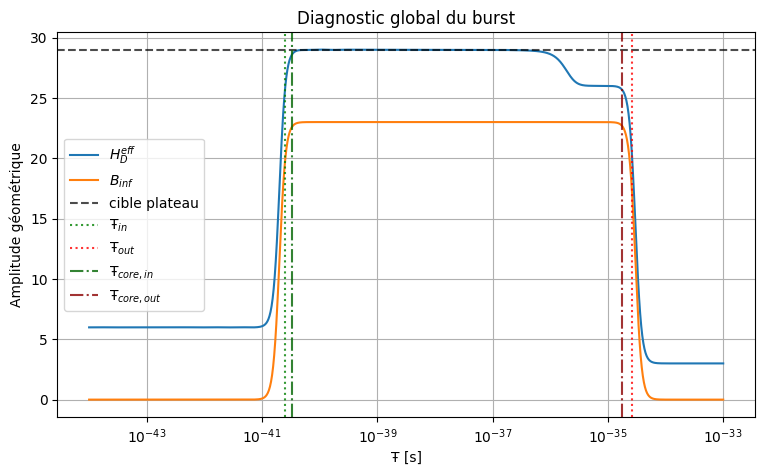

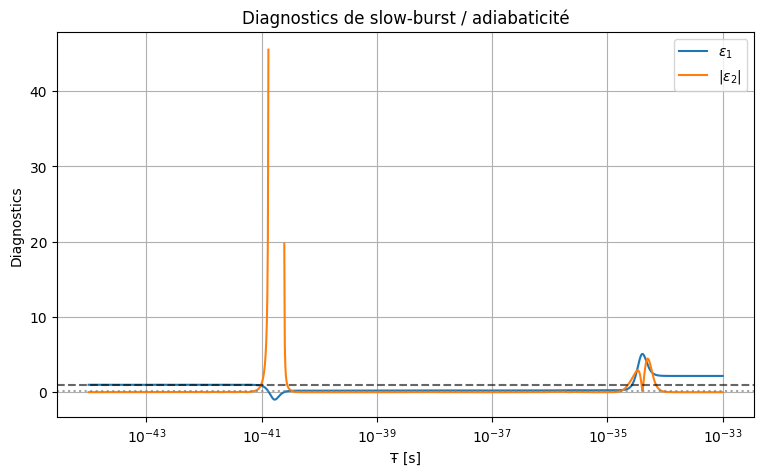

Plateau max H_D^eff = 29.003288733395596
min epsilon1 = -0.9875563798503868
max epsilon1 = 5.0839259465860325


In [7]:
plt.figure(figsize=(9,5))
plt.semilogx(grid, HDe, label=r"$H_D^{eff}$")
plt.semilogx(grid, Bv, label=r"$B_{inf}$")
plt.axhline(p["HB_target"], ls="--", color="k", alpha=0.7, label="cible plateau")
if np.isfinite(Tbar_in): plt.axvline(Tbar_in, ls=":", color="g", alpha=0.8, label=r"Ŧ$_{in}$")
if np.isfinite(Tbar_out): plt.axvline(Tbar_out, ls=":", color="r", alpha=0.8, label=r"Ŧ$_{out}$")
if np.isfinite(Tbar_core_in): plt.axvline(Tbar_core_in, ls="-.", color="darkgreen", alpha=0.8, label=r"Ŧ$_{core,in}$")
if np.isfinite(Tbar_core_out): plt.axvline(Tbar_core_out, ls="-.", color="darkred", alpha=0.8, label=r"Ŧ$_{core,out}$")
plt.xlabel("Ŧ [s]")
plt.ylabel("Amplitude géométrique")
plt.title("Diagnostic global du burst")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.semilogx(grid, eps1, label=r"$\epsilon_1$")
plt.semilogx(grid, np.abs(eps2), label=r"$|\epsilon_2|$")
plt.axhline(1.0, ls="--", color="k", alpha=0.6)
plt.axhline(p["eps2_core_max"], ls=":", color="gray", alpha=0.7)
plt.xlabel("Ŧ [s]")
plt.ylabel("Diagnostics")
plt.title("Diagnostics de slow-burst / adiabaticité")
plt.grid(True)
plt.legend()
plt.show()

print("Plateau max H_D^eff =", float(np.nanmax(HDe)))
print("min epsilon1 =", float(np.nanmin(eps1)))
print("max epsilon1 =", float(np.nanmax(eps1)))

## 7. Moyennes sur le cœur de plateau

In [8]:
def interval_mask(grid, T1, T2):
    return np.isfinite(grid) & np.isfinite(T1) & np.isfinite(T2) & (grid >= T1) & (grid <= T2)

core_interval = interval_mask(grid, Tbar_core_in, Tbar_core_out)

def mean_on_core(arr):
    if np.sum(core_interval) == 0:
        return np.nan
    return float(np.nanmean(arr[core_interval]))

def std_on_core(arr):
    if np.sum(core_interval) == 0:
        return np.nan
    return float(np.nanstd(arr[core_interval]))

summary = {
    "Hbar_D_eff_core": mean_on_core(HDe),
    "beta_core": mean_on_core(np.array([beta_of_Tbar(T, p) for T in grid])),
    "p_eff_core": mean_on_core(np.array([p_eff_of_Tbar(T, p) for T in grid])),
    "Xi_struct_core": mean_on_core(np.array([Xi_struct_of_Tbar(T, p) for T in grid])),
    "A_HD_core": mean_on_core(Ahd),
    "A_beta_core": mean_on_core(Ab),
    "eps1_core": mean_on_core(eps1),
    "eps2_core": mean_on_core(eps2),
    "sigma_tr": std_on_core(HDe),
}

for k, v in summary.items():
    print(f"{k} = {v}")

Hbar_D_eff_core = 28.447014412266626
beta_core = 1.0366506410135174
p_eff_core = 4.586792253500368
Xi_struct_core = 0.0014941758590401376
A_HD_core = 0.0024296722055419514
A_beta_core = 0.001570182398321331
eps1_core = 0.22269028475000988
eps2_core = 0.006885359856204735
sigma_tr = 1.0709919997260602


## 8. Fermeture V4.1 et pivot métrique V4.2bis

La fermeture observable est construite à partir de la **dérive adiabatique géométrique** du cœur de plateau.  
Le raccord métrique intervient ensuite seulement pour traduire le pivot en énergie via \(J = dt/d\mathrm{Ŧ}\).  

Dans cette version **V4.2bis**, le scan de fermeture tient explicitement compte de la contrainte énergétique
**après raccord métrique**, ce qui rend cohérente la sélection finale des lignes compatibles.


In [9]:
# Cellule V4.1-1 — résumé géométrique enrichi

import numpy as np
import pandas as pd
from scipy.optimize import brentq

Mpl_red = 2.435e18
hbar_GeV_s = 6.582119569e-25
g_re_default = 106.75
V14_max_GeV = 1.0e16

HDe_arr = np.array([H_D_eff_of_Tbar(T, p) for T in grid])
beta_arr = np.array([beta_of_Tbar(T, p) for T in grid])
Xi_struct_arr = np.array([Xi_struct_of_Tbar(T, p) for T in grid])
AHD_arr = np.array([A_HD_of_Tbar(T, p) for T in grid])
Abeta_arr = np.array([A_beta_of_Tbar(T, p) for T in grid])
H_arr = np.array([H_of_Tbar(T, p) for T in grid])

if "core_mask" not in globals():
    core_mask = np.isfinite(grid) & (grid >= Tbar_core_in) & (grid <= Tbar_core_out)

def _safe_mean(arr, mask):
    arr = np.asarray(arr)
    if np.sum(mask) == 0:
        return np.nan
    return float(np.nanmean(arr[mask]))

def _safe_std(arr, mask):
    arr = np.asarray(arr)
    if np.sum(mask) == 0:
        return np.nan
    return float(np.nanstd(arr[mask]))

def H_to_GeV(H_si):
    return hbar_GeV_s * H_si

def V14_from_H_GeV(H_GeV):
    return (3.0 * (Mpl_red**2) * (H_GeV**2))**0.25

def Tbar_star_from_N(N_target, T1, T2, p):
    if (not np.isfinite(T1)) or (not np.isfinite(T2)) or (T1 >= T2):
        return np.nan
    if N_target > N_between(T1, T2, p):
        return np.nan

    f = lambda x: N_between(np.exp(x), T2, p) - N_target
    x1 = np.log(T1)
    x2 = np.log(T2)

    if f(x1) * f(x2) > 0:
        return np.nan

    return float(np.exp(brentq(f, x1, x2)))

summary_V41 = {
    "Hbar_D_eff_core": _safe_mean(HDe_arr, core_mask),
    "beta_core": _safe_mean(beta_arr, core_mask),
    "Xi_struct_core": _safe_mean(Xi_struct_arr, core_mask),
    "A_HD_core": _safe_mean(AHD_arr, core_mask),
    "A_beta_core": _safe_mean(Abeta_arr, core_mask),
    "sigma_tr": _safe_std(HDe_arr, core_mask),
}

summary_V41["p_eff_core"] = summary_V41["Hbar_D_eff_core"] / (6.0 * summary_V41["beta_core"])
summary_V41["ns0_geom"] = 1.0 - 1.0 / summary_V41["Hbar_D_eff_core"]
summary_V41["sigma_tr_rel"] = summary_V41["sigma_tr"] / summary_V41["Hbar_D_eff_core"]


tableau_geo_V41 = pd.DataFrame([{
    "HB_target": p["HB_target"],
    "Tbar_on_s": p["Tbar_on"],
    "Tbar_off_s": p["Tbar_off"],
    "Tbar_max_s": p["Tbar_max"],
    "beta_lo": p["beta_lo"],
    "beta_hi": p["beta_hi"],
    "Tbar_in_s": Tbar_in,
    "Tbar_out_s": Tbar_out,
    "Tbar_core_in_s": Tbar_core_in,
    "Tbar_core_out_s": Tbar_core_out,
    "N_infl_available": N_infl_available,
    "N_core_available": N_core_available,
    **summary_V41
}])

display(tableau_geo_V41)

,HB_target,Tbar_on_s,Tbar_off_s,Tbar_max_s,beta_lo,beta_hi,Tbar_in_s,Tbar_out_s,Tbar_core_in_s,Tbar_core_out_s,...,N_core_available,Hbar_D_eff_core,beta_core,Xi_struct_core,A_HD_core,A_beta_core,sigma_tr,p_eff_core,ns0_geom,sigma_tr_rel
0,29.0,2.000000e-41,3.000000e-35,1.000000e-33,0.98,1.08,2.480250e-41,2.642520e-35,3.333771e-41,1.731937e-35,...,60.368746,28.447014,1.036651,0.001494,0.00243,0.00157,1.070992,4.573546,0.964847,0.037649


In [10]:
# Cellule V4.1-2 — fermeture observable fondée sur la dérive adiabatique géométrique

ns_target = 0.965
ns_tol = 0.01
r_max = 0.036

closure_V41 = {
    # poids de la dérive adiabatique géométrique
    "kappa_ad": 1.0,
    "nu_beta": 1.0,
    "nu_tr": 0.25,

    # fermeture de Xi
    "a1": 1.0,
    "a2": 0.0,
    "a3": 0.0,

    # corrections résiduelles fortement bornées
    "c_eta": 0.0,
    "c_xi": 0.0,
}

def evaluate_closure_V41(N_star, summary, pars):
    delta_ad_geo = (
        summary["A_HD_core"]
        + pars["nu_beta"] * summary["A_beta_core"]
        + pars["nu_tr"] * summary["sigma_tr_rel"]
    )

    # epsilon piloté par la dérive adiabatique géométrique
    eps_eff = pars["kappa_ad"] * delta_ad_geo / summary["p_eff_core"]

    # Xi reste une grandeur aval, modérée
    Xi_eff = (
        pars["a1"] * summary["Xi_struct_core"]
        + pars["a2"] * summary["A_HD_core"]
        + pars["a3"] * summary["A_beta_core"]
    )

    # ancrage sur le prior géométrique ns0_geom
    eta_eff = 0.5 * (summary["ns0_geom"] - 1.0 + 6.0 * eps_eff)               + pars["c_eta"]               + pars["c_xi"] * Xi_eff / N_star

    ns_eff = 1.0 - 6.0 * eps_eff + 2.0 * eta_eff
    r_eff = (16.0 / (3.0 * N_star)) * Xi_eff

    return {
        "N_star": float(N_star),
        "delta_ad_geo": delta_ad_geo,
        "ns0_geom": summary["ns0_geom"],
        "eps_eff": eps_eff,
        "Xi_eff": Xi_eff,
        "eta_eff": eta_eff,
        "ns_eff": ns_eff,
        "r_eff": r_eff,
        "ok_ns": abs(ns_eff - ns_target) <= ns_tol,
        "ok_r": r_eff <= r_max,
    }

tableau_test_V41 = pd.DataFrame(
    [evaluate_closure_V41(Ns, summary_V41, closure_V41) for Ns in np.arange(50, 61, 1)]
)
tableau_test_V41["ok_all"] = tableau_test_V41["ok_ns"] & tableau_test_V41["ok_r"]
display(tableau_test_V41)

,N_star,delta_ad_geo,ns0_geom,eps_eff,Xi_eff,eta_eff,ns_eff,r_eff,ok_ns,ok_r,ok_all
0,50.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000159,True,True,True
1,51.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000156,True,True,True
2,52.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000153,True,True,True
3,53.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000150,True,True,True
4,54.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000148,True,True,True
5,55.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000145,True,True,True
6,56.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000142,True,True,True
7,57.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000140,True,True,True
8,58.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000137,True,True,True
9,59.0,0.013412,0.964847,0.002933,0.001494,-0.008779,0.964847,0.000135,True,True,True


In [11]:
# Cellule V4.1-3 — pré-calcul des pivots et scan durci avec contrainte énergétique
# version autonome et allégée

import numpy as np
import pandas as pd
from scipy.optimize import brentq

V14_max_GeV = 1.0e16
Nstar_grid = np.arange(50.0, 60.1, 1.0)

def H_to_GeV(H_si):
    return hbar_GeV_s * H_si

def V14_from_H_GeV(H_GeV):
    return (3.0 * (Mpl_red**2) * (H_GeV**2))**0.25

def Tbar_star_from_N(N_target, T1, T2, p):
    if (not np.isfinite(T1)) or (not np.isfinite(T2)) or (T1 >= T2):
        return np.nan
    if N_target > N_between(T1, T2, p):
        return np.nan

    f = lambda x: N_between(np.exp(x), T2, p) - N_target
    x1 = np.log(T1)
    x2 = np.log(T2)

    if f(x1) * f(x2) > 0:
        return np.nan

    return float(np.exp(brentq(f, x1, x2)))

pivot_cache = {}
for N_star in Nstar_grid:
    Tstar = Tbar_star_from_N(float(N_star), Tbar_core_in, Tbar_core_out, p)

    if np.isfinite(Tstar):
        H_star_GeV = H_to_GeV(H_of_Tbar(Tstar, p))
        V14_star_GeV = V14_from_H_GeV(H_star_GeV)
    else:
        H_star_GeV = np.nan
        V14_star_GeV = np.nan

    pivot_cache[float(N_star)] = {
        "Tbar_star_s": Tstar,
        "H_star_GeV": H_star_GeV,
        "V14_star_GeV": V14_star_GeV,
        "ok_V14": bool(np.isfinite(V14_star_GeV) and (V14_star_GeV <= V14_max_GeV)),
    }

rows_scan_V41 = []

# scan durci mais raisonnable pour Colab
kappa_ad_grid = np.linspace(0.2, 2.0, 19)
nu_beta_grid = [0.5, 1.0, 2.0]
nu_tr_grid = [0.0, 0.25]

a1_grid = np.linspace(0.5, 3.0, 26)
c_eta_grid = np.linspace(-0.02, 0.02, 17)

for kappa_ad in kappa_ad_grid:
    for nu_beta in nu_beta_grid:
        for nu_tr in nu_tr_grid:
            for a1 in a1_grid:
                for c_eta in c_eta_grid:
                    pars = {
                        "kappa_ad": float(kappa_ad),
                        "nu_beta": float(nu_beta),
                        "nu_tr": float(nu_tr),
                        "a1": float(a1),
                        "a2": 0.0,
                        "a3": 0.0,
                        "c_eta": float(c_eta),
                        "c_xi": 0.0,
                    }

                    for N_star in Nstar_grid:
                        out = evaluate_closure_V41(float(N_star), summary_V41, pars)

                        piv = pivot_cache[float(N_star)]
                        out.update(pars)
                        out["Tbar_star_s"] = piv["Tbar_star_s"]
                        out["H_star_GeV"] = piv["H_star_GeV"]
                        out["V14_star_GeV"] = piv["V14_star_GeV"]
                        out["ok_V14"] = piv["ok_V14"]
                        out["ok_all"] = bool(out["ok_ns"] and out["ok_r"] and out["ok_V14"])

                        rows_scan_V41.append(out)

scan_V41 = pd.DataFrame(rows_scan_V41)
scan_V41["abs_ns_err"] = np.abs(scan_V41["ns_eff"] - ns_target)

scan_V41 = scan_V41.sort_values(
    by=["ok_all", "ok_V14", "ok_r", "ok_ns", "abs_ns_err", "r_eff", "V14_star_GeV", "N_star"],
    ascending=[False, False, False, False, True, True, True, True]
).reset_index(drop=True)

print("Nombre de lignes compatibles =", int(scan_V41["ok_all"].sum()))
display(scan_V41.head(20))

Nombre de lignes compatibles = 0


,N_star,delta_ad_geo,ns0_geom,eps_eff,Xi_eff,eta_eff,ns_eff,r_eff,ok_ns,ok_r,...,a2,a3,c_eta,c_xi,Tbar_star_s,H_star_GeV,V14_star_GeV,ok_V14,ok_all,abs_ns_err
0,60.0,0.012627,0.964847,0.004693,0.000747,-0.003496,0.964847,0.000066,True,True,...,0.0,0.0,0.0,0.0,3.595249e-41,8.964698e+16,6.148903e+17,False,False,0.000153
1,60.0,0.013412,0.964847,0.004985,0.000747,-0.002621,0.964847,0.000066,True,True,...,0.0,0.0,0.0,0.0,3.595249e-41,8.964698e+16,6.148903e+17,False,False,0.000153
2,60.0,0.005570,0.964847,0.002070,0.000747,-0.011365,0.964847,0.000066,True,True,...,0.0,0.0,0.0,0.0,3.595249e-41,8.964698e+16,6.148903e+17,False,False,0.000153
3,60.0,0.014982,0.964847,0.005569,0.000747,-0.000870,0.964847,0.000066,True,True,...,0.0,0.0,0.0,0.0,3.595249e-41,8.964698e+16,6.148903e+17,False,False,0.000153
4,60.0,0.005570,0.964847,0.002192,0.000747,-0.011000,0.964847,0.000066,True,True,...,0.0,0.0,0.0,0.0,3.595249e-41,8.964698e+16,6.148903e+17,False,False,0.000153
5,59.0,0.012627,0.964847,0.004693,0.000747,-0.003496,0.964847,0.000068,True,True,...,0.0,0.0,0.0,0.0,4.406598e-41,7.355122e+16,5.569609e+17,False,False,0.000153
6,59.0,0.013412,0.964847,0.004985,0.000747,-0.002621,0.964847,0.000068,True,True,...,0.0,0.0,0.0,0.0,4.406598e-41,7.355122e+16,5.569609e+17,False,False,0.000153
7,59.0,0.005570,0.964847,0.002070,0.000747,-0.011365,0.964847,0.000068,True,True,...,0.0,0.0,0.0,0.0,4.406598e-41,7.355122e+16,5.569609e+17,False,False,0.000153
8,59.0,0.014982,0.964847,0.005569,0.000747,-0.000870,0.964847,0.000068,True,True,...,0.0,0.0,0.0,0.0,4.406598e-41,7.355122e+16,5.569609e+17,False,False,0.000153
9,59.0,0.005570,0.964847,0.002192,0.000747,-0.011000,0.964847,0.000068,True,True,...,0.0,0.0,0.0,0.0,4.406598e-41,7.355122e+16,5.569609e+17,False,False,0.000153


In [12]:
# Cellule V4.2bis-1/2/3 — raccord métrique avec metric onset + J_mode

import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid

V14_target_GeV = float(globals().get("V14_target_GeV", 1.0e16))

# Modes disponibles :
#   - "legacy" : activation lisse pilotée par (Tbar_J, w_J), mais coupée par l'onset métrique
#   - "dynamic_proxy" : J suit un proxy de metricité construit à partir de A_geo
#   - "dynamic_proxy_calibrated" : même proxy, mais J0 est calibré pour saturer la cible énergétique au pivot de référence
J_MODE = globals().get("J_MODE", "dynamic_proxy_calibrated")

N_ref_candidates = list(globals().get("N_ref_candidates", [55.0, 57.0, 58.0]))
Tbar_J_candidates = list(globals().get("Tbar_J_candidates", [1.0e-38, 5.0e-39]))
w_J_candidates = list(globals().get("w_J_candidates", [0.70]))

def _arr_or_build(name, builder):
    arr = globals().get(name, None)
    if arr is None:
        arr = np.array([builder(T) for T in grid], dtype=float)
    return np.asarray(arr, dtype=float)

AHD_grid = _arr_or_build("AHD_arr", lambda T: A_HD_of_Tbar(T, p))
Abeta_grid = _arr_or_build("Abeta_arr", lambda T: A_beta_of_Tbar(T, p))
eps2_grid = _arr_or_build("eps2", lambda T: epsilon2_of_Tbar(T, p))
H_grid = _arr_or_build("H_arr", lambda T: H_of_Tbar(T, p))

A_geo_arr = np.asarray(AHD_grid + Abeta_grid, dtype=float)
cumN_raw = cumulative_trapezoid(H_grid, grid, initial=0.0)

def _first_finite(*vals):
    for v in vals:
        if v is not None and np.isfinite(v):
            return float(v)
    return np.nan

def detect_metric_onset(grid, A_geo_arr, eps2_arr, p, Tbar_core_in, Tbar_core_out, Tbar_out):
    g = np.asarray(grid, dtype=float)
    A = np.asarray(A_geo_arr, dtype=float)
    e2 = np.asarray(eps2_arr, dtype=float)

    late_start = _first_finite(Tbar_core_in, Tbar_core_out, p["Tbar_min"])
    late_end = _first_finite(Tbar_out, p["Tbar_max"])

    mask_late = np.isfinite(g) & np.isfinite(A) & (g >= late_start) & (g <= late_end)
    if np.any(mask_late):
        A_late = A[mask_late]
        A_thr = float(np.nanmedian(A_late) + 0.25 * np.nanstd(A_late))
        e2_thr = float(max(1.5 * p.get("eps2_core_max", 0.0), np.nanmedian(np.abs(e2[mask_late]))))
        cond = mask_late & (A <= A_thr)
        if np.any(np.isfinite(e2)):
            cond &= np.isfinite(e2) & (np.abs(e2) <= e2_thr)

        idx = np.where(cond)[0]
        if len(idx):
            return float(g[idx[0]]), {
                "rule": "late_stabilisation",
                "A_geo_threshold": A_thr,
                "eps2_threshold": e2_thr,
            }

    fallback = _first_finite(Tbar_core_in, Tbar_core_out, Tbar_out, p["Tbar_min"])
    return float(fallback), {
        "rule": "fallback",
        "A_geo_threshold": np.nan,
        "eps2_threshold": np.nan,
    }

T_met_on, metric_onset_meta = detect_metric_onset(
    grid, A_geo_arr, eps2_grid, p,
    globals().get("Tbar_core_in", np.nan),
    globals().get("Tbar_core_out", np.nan),
    globals().get("Tbar_out", np.nan),
)

print("J_MODE =", J_MODE)
print("T_met_on =", T_met_on)
print("metric_onset_meta =", metric_onset_meta)

def onset_gate_of_Tbar(Tbar, T_on, w_on):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    Ton = np.clip(T_on, p["Tbar_min"], p["Tbar_max"])
    return 0.5 * (1.0 + np.tanh((np.log(T) - np.log(Ton)) / w_on))

A_geo_ref_mask = np.isfinite(grid) & np.isfinite(A_geo_arr)
if np.isfinite(globals().get("Tbar_core_in", np.nan)):
    A_geo_ref_mask &= (grid >= globals()["Tbar_core_in"])
if np.isfinite(T_met_on):
    A_geo_ref_mask &= (grid <= T_met_on)
if np.sum(A_geo_ref_mask) == 0:
    A_geo_ref = float(np.nanpercentile(A_geo_arr[np.isfinite(A_geo_arr)], 90))
else:
    A_geo_ref = float(np.nanpercentile(A_geo_arr[A_geo_ref_mask], 90))
if (not np.isfinite(A_geo_ref)) or (A_geo_ref <= 0):
    A_geo_ref = float(max(np.nanmax(A_geo_arr), 1e-12))

def A_geo_of_Tbar(Tbar):
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    return float(np.interp(np.log(T), np.log(grid), A_geo_arr))

def metricity_proxy_of_Tbar(Tbar, T_on, w_on):
    gate = onset_gate_of_Tbar(Tbar, T_on, w_on)
    A = A_geo_of_Tbar(Tbar)
    x = 1.0 - np.clip(A / max(A_geo_ref, 1e-30), 0.0, 1.0)
    return float(np.clip(gate * x, 0.0, 1.0))

def J_shape_of_Tbar(Tbar, Jpars):
    w_use = float(Jpars.get("w_J", 0.70))
    T_on = float(Jpars.get("T_met_on", T_met_on))
    T = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])

    if Jpars.get("J_mode", J_MODE) == "legacy":
        T_switch = max(float(Jpars.get("Tbar_J", T_on)), T_on)
        return onset_gate_of_Tbar(T, T_switch, w_use)

    return metricity_proxy_of_Tbar(T, T_on, w_use)

def J_of_Tbar(Tbar, Jpars):
    return 1.0 + float(Jpars["J0"]) * J_shape_of_Tbar(Tbar, Jpars)

def build_metric_cache(Jpars):
    J_grid_variant = np.array([J_of_Tbar(T, Jpars) for T in grid], dtype=float)
    H_metric_grid = H_grid / J_grid_variant
    cumN_metric = cumulative_trapezoid(H_metric_grid, grid, initial=0.0)
    cumt_metric = cumulative_trapezoid(J_grid_variant, grid, initial=0.0)
    return {
        "J_grid": J_grid_variant,
        "cumN_metric": cumN_metric,
        "cumt_metric": cumt_metric,
    }

def _cum_value(T, cum_arr):
    T = np.clip(T, p["Tbar_min"], p["Tbar_max"])
    return float(np.interp(np.log(T), np.log(grid), cum_arr))

def N_between_raw_fast(T1, T2):
    if (not np.isfinite(T1)) or (not np.isfinite(T2)) or (T1 >= T2):
        return 0.0
    return _cum_value(T2, cumN_raw) - _cum_value(T1, cumN_raw)

def N_between_metricaware(T1, T2, cache):
    if (not np.isfinite(T1)) or (not np.isfinite(T2)) or (T1 >= T2):
        return 0.0
    return _cum_value(T2, cache["cumN_metric"]) - _cum_value(T1, cache["cumN_metric"])

def t_metric_of_Tbar(Tbar, cache):
    return _cum_value(Tbar, cache["cumt_metric"])

def H_metric_of_Tbar(Tbar, Jpars):
    return H_of_Tbar(Tbar, p) / J_of_Tbar(Tbar, Jpars)

def Tbar_star_from_N_metricaware(N_target, T1, T2, cache):
    if (not np.isfinite(T1)) or (not np.isfinite(T2)) or (T1 >= T2):
        return np.nan
    c1 = _cum_value(T1, cache["cumN_metric"])
    c2 = _cum_value(T2, cache["cumN_metric"])
    if N_target > (c2 - c1):
        return np.nan

    target_c = c2 - N_target
    return float(np.exp(np.interp(target_c, cache["cumN_metric"], np.log(grid))))

def split_efolds(Tstart, Tend, T_on, cache):
    if (not np.isfinite(Tstart)) or (not np.isfinite(Tend)) or (Tstart >= Tend):
        return np.nan, np.nan
    N_burst = N_between_raw_fast(Tstart, min(Tend, T_on)) if Tstart < T_on else 0.0
    N_metric = N_between_metricaware(max(Tstart, T_on), Tend, cache) if Tend > max(Tstart, T_on) else 0.0
    return float(N_burst), float(N_metric)

rows_variants = []
variant_payloads = []

nstar_values = scan_V41["N_star"].to_numpy(dtype=float)
ok_ns_arr = scan_V41["ok_ns"].to_numpy(dtype=bool)
ok_r_arr = scan_V41["ok_r"].to_numpy(dtype=bool)
abs_ns_err_arr = scan_V41["abs_ns_err"].to_numpy(dtype=float)

for N_ref in N_ref_candidates:
    for Tbar_J in Tbar_J_candidates:
        for w_J in w_J_candidates:
            Tref = Tbar_star_from_N(float(N_ref), Tbar_core_in, Tbar_core_out, p)
            if not np.isfinite(Tref):
                continue

            Jpars = {
                "J_mode": J_MODE,
                "N_ref": float(N_ref),
                "Tbar_J": float(Tbar_J),
                "w_J": float(w_J),
                "T_met_on": float(T_met_on),
                "A_geo_ref": float(A_geo_ref),
                "V14_target_GeV": float(V14_target_GeV),
                "J0": 0.0,
            }

            for _ in range(6):
                Href_raw_GeV = H_to_GeV(H_of_Tbar(Tref, p))
                V14_ref_raw = V14_from_H_GeV(Href_raw_GeV)
                Jreq_ref = float((V14_ref_raw / V14_target_GeV) ** 2)
                Sref = J_shape_of_Tbar(Tref, Jpars)

                if J_MODE == "dynamic_proxy":
                    J0 = max(Jreq_ref - 1.0, 0.0)
                else:
                    J0 = max((Jreq_ref - 1.0) / max(Sref, 1e-12), 0.0)

                Jpars["J0"] = float(J0)
                cache = build_metric_cache(Jpars)
                Tref_new = Tbar_star_from_N_metricaware(float(N_ref), Tbar_core_in, Tbar_core_out, cache)
                if (not np.isfinite(Tref_new)) or abs(np.log(Tref_new / Tref)) < 1e-6:
                    break
                Tref = Tref_new

            Href_raw_GeV = H_to_GeV(H_of_Tbar(Tref, p))
            V14_ref_raw = V14_from_H_GeV(Href_raw_GeV)
            Jreq_ref = float((V14_ref_raw / V14_target_GeV) ** 2)
            Sref = J_shape_of_Tbar(Tref, Jpars)
            if J_MODE == "dynamic_proxy":
                Jpars["J0"] = float(max(Jreq_ref - 1.0, 0.0))
            else:
                Jpars["J0"] = float(max((Jreq_ref - 1.0) / max(Sref, 1e-12), 0.0))

            cache = build_metric_cache(Jpars)
            N_ref_burst, N_ref_metric = split_efolds(Tref, Tbar_core_out, T_met_on, cache)

            metric_rows_small = []
            for N_star in Nstar_grid:
                Tstar = Tbar_star_from_N_metricaware(float(N_star), Tbar_core_in, Tbar_core_out, cache)

                if np.isfinite(Tstar):
                    Jstar = J_of_Tbar(Tstar, Jpars)
                    tstar_metric = t_metric_of_Tbar(Tstar, cache)
                    H_star_metric_GeV = H_to_GeV(H_metric_of_Tbar(Tstar, Jpars))
                    V14_metric_GeV = V14_from_H_GeV(H_star_metric_GeV)
                    N_star_burst, N_star_metric = split_efolds(Tstar, Tbar_core_out, T_met_on, cache)
                else:
                    Jstar = np.nan
                    tstar_metric = np.nan
                    H_star_metric_GeV = np.nan
                    V14_metric_GeV = np.nan
                    N_star_burst = np.nan
                    N_star_metric = np.nan

                metric_rows_small.append({
                    "N_star": float(N_star),
                    "Tbar_star_s": Tstar,
                    "J_star": Jstar,
                    "t_star_metric_s": tstar_metric,
                    "H_star_metric_GeV": H_star_metric_GeV,
                    "V14_metric_GeV": V14_metric_GeV,
                    "ok_V14_metric": bool(np.isfinite(V14_metric_GeV) and (V14_metric_GeV <= V14_target_GeV)),
                    "N_star_burst": N_star_burst,
                    "N_star_metric": N_star_metric,
                })

            metric_df_small = pd.DataFrame(metric_rows_small)

            ok_v14_map = dict(zip(metric_df_small["N_star"], metric_df_small["ok_V14_metric"]))
            v14_metric_map = dict(zip(metric_df_small["N_star"], metric_df_small["V14_metric_GeV"]))

            ok_v14_arr = np.array([bool(ok_v14_map.get(v, False)) for v in nstar_values], dtype=bool)
            v14_metric_arr = np.array([float(v14_metric_map.get(v, np.nan)) for v in nstar_values], dtype=float)

            ok_all_metric_arr = ok_ns_arr & ok_r_arr & ok_v14_arr
            n_ok = int(np.sum(ok_all_metric_arr))

            if n_ok:
                mean_abs_ns_err = float(np.nanmean(abs_ns_err_arr[ok_all_metric_arr]))
                mean_V14 = float(np.nanmean(v14_metric_arr[ok_all_metric_arr]))
                max_N_ok = float(np.nanmax(nstar_values[ok_all_metric_arr]))
            else:
                mean_abs_ns_err = np.inf
                mean_V14 = np.inf
                max_N_ok = np.nan

            rows_variants.append({
                "J_mode": J_MODE,
                "N_ref_total": float(N_ref),
                "N_ref_burst": float(N_ref_burst) if np.isfinite(N_ref_burst) else np.nan,
                "N_ref_metric": float(N_ref_metric) if np.isfinite(N_ref_metric) else np.nan,
                "Tbar_J": float(Tbar_J),
                "w_J": float(w_J),
                "T_met_on_s": float(T_met_on),
                "Tref": Tref,
                "Href_raw_GeV": Href_raw_GeV,
                "V14_ref_raw": V14_ref_raw,
                "Jshape_ref": float(Sref),
                "Jreq_ref": Jreq_ref,
                "J0": Jpars["J0"],
                "n_ok_all_metric": n_ok,
                "max_N_ok": max_N_ok,
                "mean_abs_ns_err_compat": mean_abs_ns_err,
                "mean_V14_compat": mean_V14,
            })
            variant_payloads.append({
                "params": dict(Jpars),
                "metric_df_small": metric_df_small,
                "cache": cache,
            })

raccord_variants_V42bis = pd.DataFrame(rows_variants).sort_values(
    by=["n_ok_all_metric", "max_N_ok", "mean_abs_ns_err_compat", "mean_V14_compat"],
    ascending=[False, False, True, True]
).reset_index(drop=True)

display(raccord_variants_V42bis)

best_variant = raccord_variants_V42bis.iloc[0].to_dict()
print("Meilleure variante de raccord :")
print(best_variant)

payload_best = None
for payload in variant_payloads:
    pars = payload["params"]
    if (
        pars["J_mode"] == best_variant["J_mode"]
        and np.isclose(pars["N_ref"], best_variant["N_ref_total"])
        and np.isclose(pars["Tbar_J"], best_variant["Tbar_J"])
        and np.isclose(pars["w_J"], best_variant["w_J"])
    ):
        payload_best = payload
        break

Jpars_best = payload_best["params"]
metric_df_best = payload_best["metric_df_small"].copy()
metric_cache_best = payload_best["cache"]

scan_base_V42bis = scan_V41.drop(columns=["Tbar_star_s"], errors="ignore")
scan_V42bis = scan_base_V42bis.merge(metric_df_best, on="N_star", how="left")
scan_V42bis["J_mode"] = J_MODE
scan_V42bis["T_met_on_s"] = float(T_met_on)
scan_V42bis["N_star_total"] = scan_V42bis["N_star"]
scan_V42bis["ok_all_metric"] = scan_V42bis["ok_ns"] & scan_V42bis["ok_r"] & scan_V42bis["ok_V14_metric"]

scan_V42bis = scan_V42bis.sort_values(
    by=["ok_all_metric", "ok_V14_metric", "ok_r", "ok_ns", "abs_ns_err", "r_eff", "V14_metric_GeV", "N_star_total"],
    ascending=[False, False, False, False, True, True, True, True]
).reset_index(drop=True)

print("Nombre de lignes totalement compatibles (scan metric-aware) =", int(scan_V42bis["ok_all_metric"].sum()))
display(scan_V42bis.head(20))

best_metric = scan_V42bis[scan_V42bis["ok_all_metric"]].head(1).copy()
if len(best_metric) == 0:
    best_metric = scan_V42bis.head(1).copy()

best_V42bis = best_metric.iloc[0].to_dict()
print("Meilleure fermeture metric-aware :")
print(best_V42bis)

J_dyn_arr = np.array([J_of_Tbar(T, Jpars_best) for T in grid], dtype=float)

rows_pivot_V42bis = []

pars = {
    "kappa_ad": best_V42bis["kappa_ad"],
    "nu_beta": best_V42bis["nu_beta"],
    "nu_tr": best_V42bis["nu_tr"],
    "a1": best_V42bis["a1"],
    "a2": best_V42bis["a2"],
    "a3": best_V42bis["a3"],
    "c_eta": best_V42bis["c_eta"],
    "c_xi": best_V42bis["c_xi"],
}

for N_star in Nstar_grid:
    row_small = metric_df_best.loc[np.isclose(metric_df_best["N_star"], float(N_star))].iloc[0]
    Tstar = row_small["Tbar_star_s"]
    if not np.isfinite(Tstar):
        continue

    out = evaluate_closure_V41(float(N_star), summary_V41, pars)
    H_star_raw_GeV = H_to_GeV(H_of_Tbar(Tstar, p))

    rows_pivot_V42bis.append({
        "J_mode": J_MODE,
        "T_met_on_s": float(T_met_on),
        "N_star_total": float(N_star),
        "N_star_burst": row_small["N_star_burst"],
        "N_star_metric": row_small["N_star_metric"],
        "Tbar_star_s": Tstar,
        "t_star_metric_s": row_small["t_star_metric_s"],
        "J_star": row_small["J_star"],
        "H_star_raw_GeV": H_star_raw_GeV,
        "H_star_metric_GeV": row_small["H_star_metric_GeV"],
        "V14_metric_GeV": row_small["V14_metric_GeV"],
        "Xi_struct_star": Xi_struct_of_Tbar(Tstar, p),
        "A_geo_star": A_geo_of_Tbar(Tstar),
        "delta_ad_geo": out["delta_ad_geo"],
        "ns0_geom": out["ns0_geom"],
        "eps_eff": out["eps_eff"],
        "Xi_eff": out["Xi_eff"],
        "eta_eff": out["eta_eff"],
        "ns_eff": out["ns_eff"],
        "r_eff": out["r_eff"],
        "ok_ns": out["ok_ns"],
        "ok_r": out["ok_r"],
        "ok_V14_metric": row_small["ok_V14_metric"],
        "ok_all_metric": bool(out["ok_ns"] and out["ok_r"] and row_small["ok_V14_metric"]),
    })

tableau_pivot_V42bis = pd.DataFrame(rows_pivot_V42bis)
if "ok_all_metric" not in tableau_pivot_V42bis.columns:
    tableau_pivot_V42bis["ok_all_metric"] = pd.Series(dtype=bool)
display(tableau_pivot_V42bis)
print("Nombre de lignes totalement compatibles (pivot final) =", int(tableau_pivot_V42bis["ok_all_metric"].sum()))

diag_metric_onset_V42bis = pd.DataFrame({
    "Tbar_s": grid,
    "A_geo": A_geo_arr,
    "J_dyn": J_dyn_arr,
})



J_MODE = dynamic_proxy_calibrated
T_met_on = 3.6277138871342555e-41
metric_onset_meta = {'rule': 'late_stabilisation', 'A_geo_threshold': 0.011524790607903878, 'eps2_threshold': 0.30000000000000004}


,J_mode,N_ref_total,N_ref_burst,N_ref_metric,Tbar_J,w_J,T_met_on_s,Tref,Href_raw_GeV,V14_ref_raw,Jshape_ref,Jreq_ref,J0,n_ok_all_metric,max_N_ok,mean_abs_ns_err_compat,mean_V14_compat
0,dynamic_proxy_calibrated,55.0,0.0,2.247043,1.000000e-38,0.7,3.627714e-41,9.921331e-41,3.272245e+16,3.714948e+17,0.935574,1380.083785,1474.051214,0,NaN,inf,inf
1,dynamic_proxy_calibrated,55.0,0.0,2.247043,5.000000e-39,0.7,3.627714e-41,9.921331e-41,3.272245e+16,3.714948e+17,0.935574,1380.083785,1474.051214,0,NaN,inf,inf
2,dynamic_proxy_calibrated,57.0,0.0,2.218553,1.000000e-38,0.7,3.627714e-41,6.612887e-41,4.905098e+16,4.548347e+17,0.837138,2068.746439,2470.017146,0,NaN,inf,inf
3,dynamic_proxy_calibrated,57.0,0.0,2.218553,5.000000e-39,0.7,3.627714e-41,6.612887e-41,4.905098e+16,4.548347e+17,0.837138,2068.746439,2470.017146,0,NaN,inf,inf
4,dynamic_proxy_calibrated,58.0,0.0,2.206766,1.000000e-38,0.7,3.627714e-41,5.398309e-41,6.008098e+16,5.033827e+17,0.753682,2533.941587,3360.754508,0,NaN,inf,inf
5,dynamic_proxy_calibrated,58.0,0.0,2.206766,5.000000e-39,0.7,3.627714e-41,5.398309e-41,6.008098e+16,5.033827e+17,0.753682,2533.941587,3360.754508,0,NaN,inf,inf


Meilleure variante de raccord :
{'J_mode': 'dynamic_proxy_calibrated', 'N_ref_total': 55.0, 'N_ref_burst': 0.0, 'N_ref_metric': 2.247042685147356, 'Tbar_J': 1e-38, 'w_J': 0.7, 'T_met_on_s': 3.6277138871342555e-41, 'Tref': 9.92133141623605e-41, 'Href_raw_GeV': 3.2722453593541156e+16, 'V14_ref_raw': 3.714947893842104e+17, 'Jshape_ref': 0.9355738610601896, 'Jreq_ref': 1380.0837853961884, 'J0': 1474.0512136940365, 'n_ok_all_metric': 0, 'max_N_ok': nan, 'mean_abs_ns_err_compat': inf, 'mean_V14_compat': inf}
Nombre de lignes totalement compatibles (scan metric-aware) = 0


,N_star,delta_ad_geo,ns0_geom,eps_eff,Xi_eff,eta_eff,ns_eff,r_eff,ok_ns,ok_r,...,t_star_metric_s,H_star_metric_GeV,V14_metric_GeV,ok_V14_metric,N_star_burst,N_star_metric,J_mode,T_met_on_s,N_star_total,ok_all_metric
0,60.0,0.012627,0.964847,0.004693,0.000747,-0.003496,0.964847,0.000066,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,60.0,False
1,60.0,0.013412,0.964847,0.004985,0.000747,-0.002621,0.964847,0.000066,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,60.0,False
2,60.0,0.005570,0.964847,0.002070,0.000747,-0.011365,0.964847,0.000066,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,60.0,False
3,60.0,0.014982,0.964847,0.005569,0.000747,-0.000870,0.964847,0.000066,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,60.0,False
4,60.0,0.005570,0.964847,0.002192,0.000747,-0.011000,0.964847,0.000066,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,60.0,False
5,59.0,0.012627,0.964847,0.004693,0.000747,-0.003496,0.964847,0.000068,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,59.0,False
6,59.0,0.013412,0.964847,0.004985,0.000747,-0.002621,0.964847,0.000068,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,59.0,False
7,59.0,0.005570,0.964847,0.002070,0.000747,-0.011365,0.964847,0.000068,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,59.0,False
8,59.0,0.014982,0.964847,0.005569,0.000747,-0.000870,0.964847,0.000068,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,59.0,False
9,59.0,0.005570,0.964847,0.002192,0.000747,-0.011000,0.964847,0.000068,True,True,...,NaN,NaN,NaN,False,NaN,NaN,dynamic_proxy_calibrated,3.627714e-41,59.0,False


Meilleure fermeture metric-aware :
{'N_star': 60.0, 'delta_ad_geo': 0.012626928634107484, 'ns0_geom': 0.964846926095387, 'eps_eff': 0.00469346545206296, 'Xi_eff': 0.0007470879295200688, 'eta_eff': -0.0034961405961176084, 'ns_eff': 0.9648469260953871, 'r_eff': 6.640781595733944e-05, 'ok_ns': True, 'ok_r': True, 'kappa_ad': 1.7, 'nu_beta': 0.5, 'nu_tr': 0.25, 'a1': 0.5, 'a2': 0.0, 'a3': 0.0, 'c_eta': 0.0, 'c_xi': 0.0, 'H_star_GeV': 8.964697721879701e+16, 'V14_star_GeV': 6.148902710777754e+17, 'ok_V14': False, 'ok_all': False, 'abs_ns_err': 0.00015307390461283266, 'Tbar_star_s': nan, 'J_star': nan, 't_star_metric_s': nan, 'H_star_metric_GeV': nan, 'V14_metric_GeV': nan, 'ok_V14_metric': False, 'N_star_burst': nan, 'N_star_metric': nan, 'J_mode': 'dynamic_proxy_calibrated', 'T_met_on_s': 3.6277138871342555e-41, 'N_star_total': 60.0, 'ok_all_metric': False}


,ok_all_metric


Nombre de lignes totalement compatibles (pivot final) = 0


In [13]:
# Cellule V4.2bis-4 — Reheating conditionnel basé sur le pivot métrique / fin métrique

import numpy as np
import pandas as pd

def rho_from_H_GeV(H_GeV):
    return 3.0 * (Mpl_red**2) * (H_GeV**2)

def T_re_from_rho_re(rho_re, g_re=g_re_default):
    return ((30.0 * rho_re) / (np.pi**2 * g_re))**0.25

rows_re_V42bis = []

H_met_on_metric_GeV = H_to_GeV(H_metric_of_Tbar(T_met_on, Jpars_best)) if np.isfinite(T_met_on) else np.nan
H_end_full_metric_GeV = H_to_GeV(H_metric_of_Tbar(Tbar_out, Jpars_best)) if np.isfinite(Tbar_out) else np.nan
H_end_core_metric_GeV = H_to_GeV(H_metric_of_Tbar(Tbar_core_out, Jpars_best)) if np.isfinite(Tbar_core_out) else np.nan

for ref_label, Href in [
    ("metric_onset", H_met_on_metric_GeV),
    ("fin_inflation_complete_metric", H_end_full_metric_GeV),
    ("fin_coeur_plateau_metric", H_end_core_metric_GeV),
]:
    if not np.isfinite(Href):
        continue

    rho_ref = rho_from_H_GeV(Href)

    rows_re_V42bis.append({
        "J_mode": J_MODE,
        "T_met_on_s": float(T_met_on),
        "hypothese": "instantane",
        "reference": ref_label,
        "w_re": np.nan,
        "N_re": 0.0,
        "H_ref_GeV": Href,
        "rho_ref_14_GeV": rho_ref**0.25,
        "T_re_GeV": T_re_from_rho_re(rho_ref),
    })

    for w_re in [0.0, 1.0/6.0, 0.25]:
        for N_re in [5.0, 10.0]:
            rho_re = rho_ref * np.exp(-3.0 * (1.0 + w_re) * N_re)
            rows_re_V42bis.append({
                "J_mode": J_MODE,
                "T_met_on_s": float(T_met_on),
                "hypothese": "conditionnel",
                "reference": ref_label,
                "w_re": w_re,
                "N_re": N_re,
                "H_ref_GeV": Href,
                "rho_ref_14_GeV": rho_ref**0.25,
                "T_re_GeV": T_re_from_rho_re(rho_re),
            })

tableau_re_V42bis = pd.DataFrame(rows_re_V42bis)
display(tableau_re_V42bis)



,J_mode,T_met_on_s,hypothese,reference,w_re,N_re,H_ref_GeV,rho_ref_14_GeV,T_re_GeV
0,dynamic_proxy_calibrated,3.627714e-41,instantane,metric_onset,NaN,0.0,2.609067e+14,3.317206e+16,1.362655e+16
1,dynamic_proxy_calibrated,3.627714e-41,conditionnel,metric_onset,0.000000,5.0,2.609067e+14,3.317206e+16,3.204657e+14
2,dynamic_proxy_calibrated,3.627714e-41,conditionnel,metric_onset,0.000000,10.0,2.609067e+14,3.317206e+16,7.536631e+12
3,dynamic_proxy_calibrated,3.627714e-41,conditionnel,metric_onset,0.166667,5.0,2.609067e+14,3.317206e+16,1.715329e+14
4,dynamic_proxy_calibrated,3.627714e-41,conditionnel,metric_onset,0.166667,10.0,2.609067e+14,3.317206e+16,2.159281e+12
5,dynamic_proxy_calibrated,3.627714e-41,conditionnel,metric_onset,0.250000,5.0,2.609067e+14,3.317206e+16,1.254962e+14
6,dynamic_proxy_calibrated,3.627714e-41,conditionnel,metric_onset,0.250000,10.0,2.609067e+14,3.317206e+16,1.155780e+12
7,dynamic_proxy_calibrated,3.627714e-41,instantane,fin_inflation_complete_metric,NaN,0.0,7.642483e+10,5.677368e+14,2.332171e+14
8,dynamic_proxy_calibrated,3.627714e-41,conditionnel,fin_inflation_complete_metric,0.000000,5.0,7.642483e+10,5.677368e+14,5.484741e+12
9,dynamic_proxy_calibrated,3.627714e-41,conditionnel,fin_inflation_complete_metric,0.000000,10.0,7.642483e+10,5.677368e+14,1.289887e+11


## 9. Exports CSV V4.2bis


In [14]:
# Cellule V4.2bis-5 — Exports CSV

tableau_geo_V41.to_csv("V42bis_tableau1_geometrie.csv", index=False)
tableau_pivot_V42bis.to_csv("V42bis_tableau2_pivot_metric.csv", index=False)
scan_V42bis.to_csv("V42bis_tableau3_scan_metric_closure.csv", index=False)
tableau_re_V42bis.to_csv("V42bis_tableau4_reheating_conditionnel.csv", index=False)

best_metric.to_csv("V42bis_best_closure_metric.csv", index=False)
raccord_variants_V42bis.to_csv("V42bis_raccord_variants.csv", index=False)

summary_J_V42bis = pd.DataFrame([best_variant])
summary_J_V42bis.to_csv("V42bis_raccord_jacobian.csv", index=False)
diag_metric_onset_V42bis.to_csv("V42bis_metric_onset_diagnostics.csv", index=False)

print("Exports créés :")
print(" - V42bis_tableau1_geometrie.csv")
print(" - V42bis_tableau2_pivot_metric.csv")
print(" - V42bis_tableau3_scan_metric_closure.csv")
print(" - V42bis_tableau4_reheating_conditionnel.csv")
print(" - V42bis_best_closure_metric.csv")
print(" - V42bis_raccord_variants.csv")
print(" - V42bis_raccord_jacobian.csv")
print(" - V42bis_metric_onset_diagnostics.csv")



Exports créés :
 - V42bis_tableau1_geometrie.csv
 - V42bis_tableau2_pivot_metric.csv
 - V42bis_tableau3_scan_metric_closure.csv
 - V42bis_tableau4_reheating_conditionnel.csv
 - V42bis_best_closure_metric.csv
 - V42bis_raccord_variants.csv
 - V42bis_raccord_jacobian.csv
 - V42bis_metric_onset_diagnostics.csv
